


$$
\nabla
\partial
$$

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
rng = np.random.default_rng(seed=42)

In [69]:
fp = "mnist.csv"
df = pd.read_csv(fp)
df.reset_index(drop=True, inplace=True)
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [70]:
df = df.T
df

,0,1,2,3,4,5,6,7,8,9,...,41990,41991,41992,41993,41994,41995,41996,41997,41998,41999
label,1,0,1,4,0,0,7,3,5,3,...,3,1,9,6,4,0,1,7,6,9
pixel0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel779,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel780,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel781,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel782,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [71]:
df.to_numpy()[0:3, ]

array([[1, 0, 1, ..., 7, 6, 9],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3, 42000))

In [89]:
ds = df.to_numpy()
ds = rng.permutation(ds, axis=1)        # Perturb matrix columns

assert np.isnan(ds).sum() == 0      # No NaNs!!!

def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

m, n = ds.shape
X_train = normalize(ds[1: ,0:int(0.75*n)])
Y_train = ds[0,0:int(0.75*n)]

X_test = normalize(ds[1: ,int(0.75*n): ])
Y_test = ds[0,int(0.75*n): ]

Y_train_one_hot = np.eye(10)[Y_train].T
Y_test_one_hot = np.eye(10)[Y_test].T


print(X_train.shape, Y_train_one_hot.shape, X_test.shape, Y_test_one_hot.shape)

(784, 31500) (10, 31500) (784, 10500) (10, 10500)


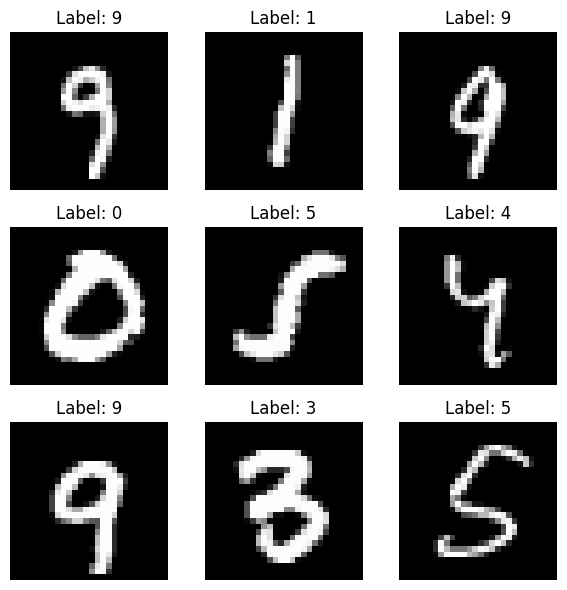

In [94]:
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()  # Flatten the 2D array of axes for easy looping

for i in range(9):
    # Pick a random index from the training set
    idx = rng.integers(0, X_train.shape[1])
    
    # 1. Reshape the flat 784 pixels back into a 28x28 image
    img = X_train[:,idx].reshape(28, 28)
    
    # 2. Plot the image (cmap='gray' shows it in black and white)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {Y_train[idx]}")
    axes[i].axis('off')  # Hide pixel coordinate axes

plt.tight_layout()
plt.show()


In [117]:
# Define model

def relu(Z):
    return np.maximum(0, Z)     # element-wise

def relu_prime(Z):
    return (Z > 0).astype(int)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def cce(Y_hat, Y):
    eps = 1e-15
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    return -np.mean(np.sum(Y * np.log(Y_hat), axis=0))

def forward(
        X,
        W1, b1,
        W2, b2,
        W3, b3
):
    A0 = X
    
    Z1 = W1 @ A0 + b1
    A1 = relu(Z1)

    Z2 = W2 @ A1 + b2
    A2 = relu(Z2)

    Z3 = W3 @ A2 + b3
    A3 = softmax(Z3)

    return {
        "A3":A3, "Z3":Z3,
        "A2":A2, "Z2":Z2, 
        "A1":A1, "Z1":Z1, 
        "A0":A0,
        "W3":W3, "b3":b3,
        "W2":W2, "b2":b2,
        "W1":W1, "b1":b1
    }


def backward(cache, Y, N):
    A3     = cache["A3"]
    A2, Z2 = cache["A2"], cache["Z2"]
    A1, Z1 = cache["A1"], cache["Z1"]
    A0     = cache["A0"]
    W3     = cache["W3"]
    W2     = cache["W2"]

    dZ3 = (A3 - Y) / N      # make future computations batch insensitive
    dW3 = dZ3 @ A2.T
    db3 = np.sum(dZ3, axis=1, keepdims=True)

    dZ2 = (W3.T @ dZ3) * relu_prime(Z2)
    dW2 = dZ2 @ A1.T
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = (W2.T @ dZ2) * relu_prime(Z1)
    dW1 = dZ1 @ A0.T
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    return {
        "dW1":dW1, "db1":db1,
        "dW2":dW2, "db2":db2,
        "dW3":dW3, "db3":db3    
    }

Epoch 1/10 -> Loss: 0.3115 | Accuracy: 90.97%
Epoch 2/10 -> Loss: 0.2426 | Accuracy: 92.81%
Epoch 3/10 -> Loss: 0.2019 | Accuracy: 94.07%
Epoch 4/10 -> Loss: 0.1716 | Accuracy: 94.95%
Epoch 5/10 -> Loss: 0.1483 | Accuracy: 95.64%
Epoch 6/10 -> Loss: 0.1309 | Accuracy: 96.17%
Epoch 7/10 -> Loss: 0.1167 | Accuracy: 96.57%
Epoch 8/10 -> Loss: 0.1050 | Accuracy: 96.93%
Epoch 9/10 -> Loss: 0.0954 | Accuracy: 97.19%
Epoch 10/10 -> Loss: 0.0873 | Accuracy: 97.46%


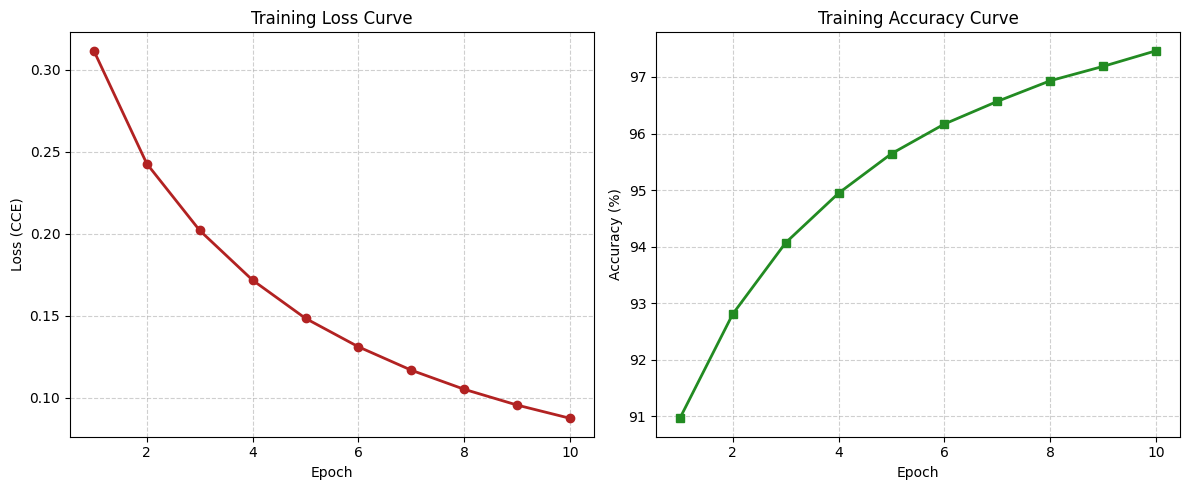

In [128]:
# Train!
N = 150     # batch size
ada = 0.1   # learning rate
epochs = 10

loss_history = []
accuracy_history = []

# init weigths and biases
# Scale by sqrt(2 / neurons_in)
W1 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 784), size=(64, 784))
b1 = np.zeros((64, 1))

W2 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 64), size=(64, 64))
b2 = np.zeros((64, 1))

W3 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 64), size=(10, 64))
b3 = np.zeros((10, 1))

for epoch in range(epochs):
    epoch_loss = 0
    correct_predictions = 0
    total_samples = X_train.shape[1]
    
    for i in range(0, X_train.shape[1], N):
        cache = forward(
            X_train[ : ,i:i+N],
            W1, b1,
            W2, b2,
            W3, b3        
        )

        grads = backward(cache, Y_train_one_hot[ : ,i:i+N], N)

        W1 -= ada*grads["dW1"]
        b1 -= ada*grads["db1"]

        W2 -= ada*grads["dW2"]
        b2 -= ada*grads["db2"]

        W3 -= ada*grads["dW3"]
        b3 -= ada*grads["db3"]

    # --- END OF EPOCH EVALUATION ---
    # Run one full forward pass across the training data to get clean epoch-level metrics
    full_cache = forward(X_train, W1, b1, W2, b2, W3, b3)
    
    # Calculate CCE Cost
    current_loss = cce(full_cache["A3"], Y_train_one_hot)
    loss_history.append(current_loss)
    
    # Calculate Accuracy 
    predictions = np.argmax(full_cache["A3"], axis=0)
    targets = np.argmax(Y_train_one_hot, axis=0)
    current_accuracy = np.mean(predictions == targets) * 100
    accuracy_history.append(current_accuracy)
    
    print(f"Epoch {epoch+1}/{epochs} -> Loss: {current_loss:.4f} | Accuracy: {current_accuracy:.2f}%")

# --- PLOTTING PERFORMANCE METRICS ---
plt.figure(figsize=(12, 5))

# Plot 1: Categorical Cross-Entropy Loss Curve
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='firebrick', linewidth=2)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (CCE)')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), accuracy_history, marker='s', color='forestgreen', linewidth=2)
plt.title('Training Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [130]:
test_cache = forward(X_test, W1, b1, W2, b2, W3, b3)

test_loss = cce(test_cache["A3"], Y_test_one_hot)

predictions = np.argmax(test_cache["A3"], axis=0)
targets = np.argmax(Y_test_one_hot, axis=0)
test_accuracy = np.mean(predictions == targets) * 100
test_accuracy

np.float64(96.03809523809524)

In [ ]:
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()  # Flatten the 2D array of axes for easy looping

for i in range(9):
    # Pick a random index from the training set
    idx = rng.integers(0, X_train.shape[1])
    
    # 1. Reshape the flat 784 pixels back into a 28x28 image
    img = X_train[:,idx].reshape(28, 28)
    
    # 2. Plot the image (cmap='gray' shows it in black and white)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {Y_train[idx]}")
    axes[i].axis('off')  # Hide pixel coordinate axes

plt.tight_layout()
plt.show()


X = X_train